# HR diagram & dimensionality reduction

We can use samples of measured data to train a data-driven basis that better explains it.

In [39]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x12552b1d0>)

In [40]:
import pandas as pd
df_stars = pd.read_csv("stars.csv")
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [41]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_
print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


In [42]:
ce = LabelEncoder()
df_stars['Star color'] = ce.fit_transform(df_stars['Star color'])
colors = ce.inverse_transform(df_stars['Star color'])
color_names = ce.classes_
print(color_names)

['Blue' 'Blue ' 'Blue White' 'Blue white' 'Blue white ' 'Blue-White'
 'Blue-white' 'Orange' 'Orange-Red' 'Pale yellow orange' 'Red' 'White'
 'White-Yellow' 'Whitish' 'Yellowish' 'Yellowish White' 'white'
 'yellow-white' 'yellowish']


In [43]:
sc = LabelEncoder()
df_stars['Spectral Class'] = sc.fit_transform(df_stars['Spectral Class'])
spectral_classes = sc.inverse_transform(df_stars['Spectral Class'])
spectral_class_names = sc.classes_
print(spectral_class_names)

['A' 'B' 'F' 'G' 'K' 'M' 'O']


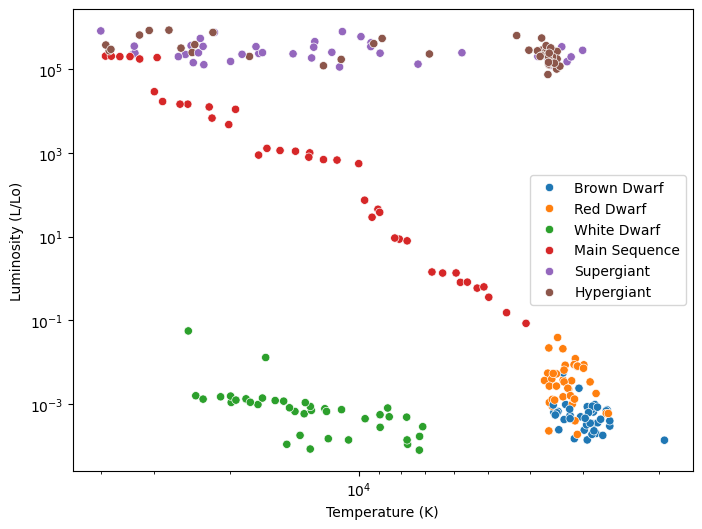

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_stars,
    x='Temperature (K)',
    y='Luminosity(L/Lo)',
    hue=le.inverse_transform(df_stars['Star type'].values),
)
plt.xscale('log')
plt.gca().invert_xaxis()
plt.yscale('log')
plt.xlabel('Temperature (K)')
plt.ylabel('Luminosity (L/Lo)')
plt.show()

Preprocessing data allow for a better analysis.

In [47]:
from sklearn.decomposition import PCA
import numpy as np
import sklearn.preprocessing as preprocessing

In [115]:
data = df_stars.drop(columns=['Star type', 'Star color', 'Spectral Class'])

# Standardize the data manually, but at the end preferably use 
# StandardScaler from sklearn.preprocessing
#
# data = data - data.mean()
# data = np.log1p(data - data.min())
# data = data / data.std()

scaler = preprocessing.StandardScaler()
data_scaled = scaler.fit_transform(data)

n_components = len(data.columns)

pca = PCA(n_components, svd_solver='full')
pca.fit(data_scaled)

eigenvalues = pca.explained_variance_
eigenvectors = pca.components_

print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues: [2.42439729 0.94396455 0.37474725 0.2736273 ]
Eigenvectors:
 [[-0.35018343 -0.55933789 -0.47477107  0.58232734]
 [ 0.82161262  0.00452564 -0.56898115  0.03453503]
 [-0.37607837  0.75509623 -0.53314117  0.06446119]
 [ 0.24675763  0.34198002  0.40818302  0.80965855]]


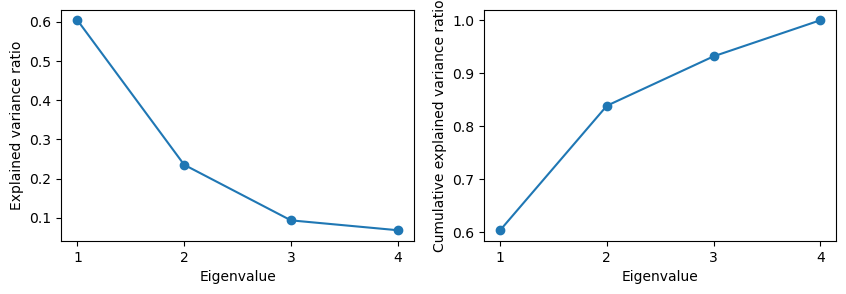

In [116]:
evals = pca.explained_variance_ratio_

fig = plt.figure(figsize=(10, 3))

ax = fig.add_subplot(121)
ax.plot(range(1, n_components+1), evals)
ax.scatter(range(1, n_components+1), evals)
ax.set_xlabel("Eigenvalue")
ax.set_ylabel("Explained variance ratio")
ax.set_xticks(range(1, n_components+1))

ax = fig.add_subplot(122)
ax.plot(range(1, n_components+1), evals.cumsum())
ax.scatter(range(1, n_components+1), evals.cumsum())
ax.set_xticks(range(1, n_components+1))
ax.set_xlabel("Eigenvalue")
ax.set_ylabel("Cumulative explained variance ratio")

plt.show()

In [117]:
cum_evals = evals.cumsum()
print("Explained variance ratio for 3 component:", cum_evals[2])
print("Explained variance ratio for 2 component:", cum_evals[1])

Explained variance ratio for 3 component: 0.9318782024519136
Explained variance ratio for 2 component: 0.8385817508043479


We can explain the $ 90-95\% $ of the variance of our data with the first three component. If we accept $83 \%$ we can use only two component.

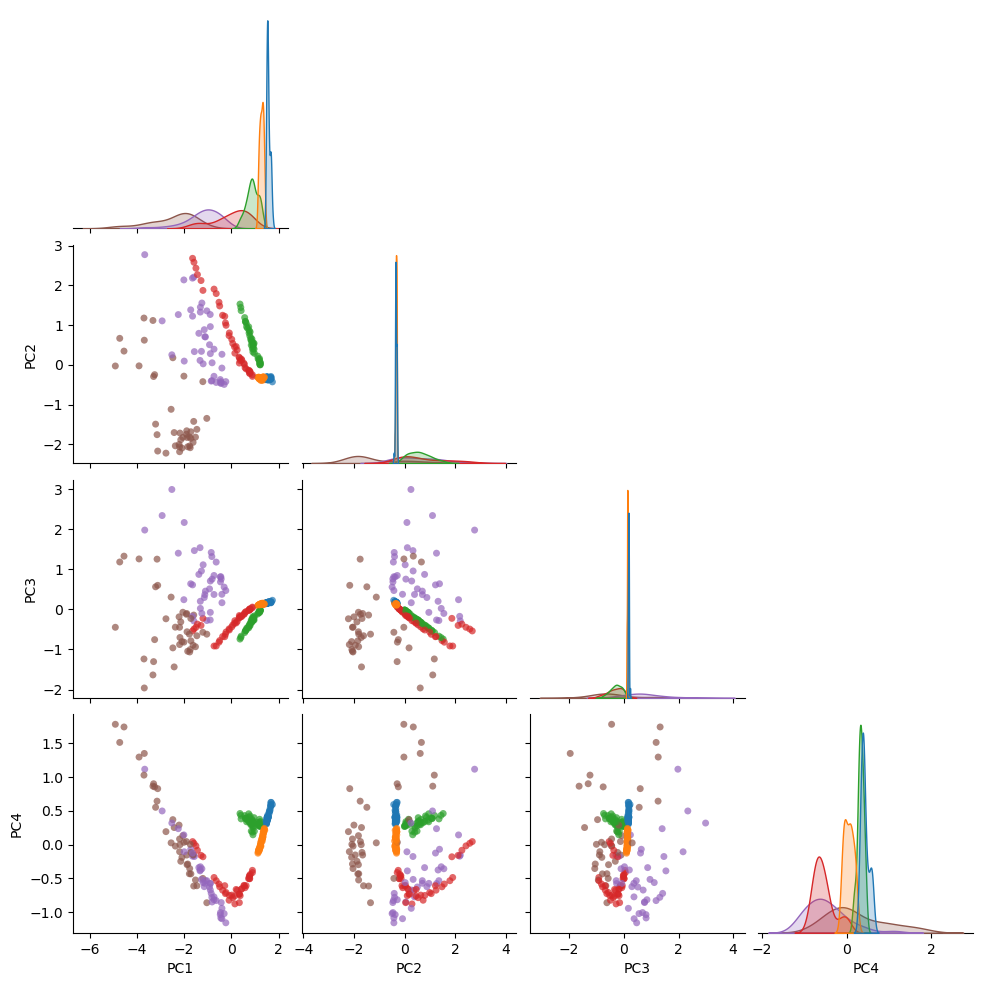

In [59]:
data_scaled_pca = pca.transform(data_scaled)

pc_columns = [f"PC{i+1}" for i in range(data_scaled_pca.shape[1])]
pc_df = pd.DataFrame(data_scaled_pca, columns=pc_columns)
pc_df["Star type"] = le.inverse_transform(df_stars["Star type"].values)

g = sns.pairplot(
    pc_df,
    vars=pc_columns,
    hue="Star type",
    corner=True,
    plot_kws={"alpha": 0.7, "s": 25, "edgecolor": "none"},
)

if hasattr(g, "_legend") and g._legend is not None:
    g._legend.remove()
plt.show()

Let's use now KMeans after dimensionality reduction. I will use 2 principal component and try to see if KMeans is capable of reconize the Star Type label.

In [110]:
n_components = 2
n_clusters = 6

In [111]:
data_scaled_pca_cl = data_scaled_pca[:, :n_components]

In [112]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(data_scaled_pca_cl)
kmeans_labels = kmeans.labels_

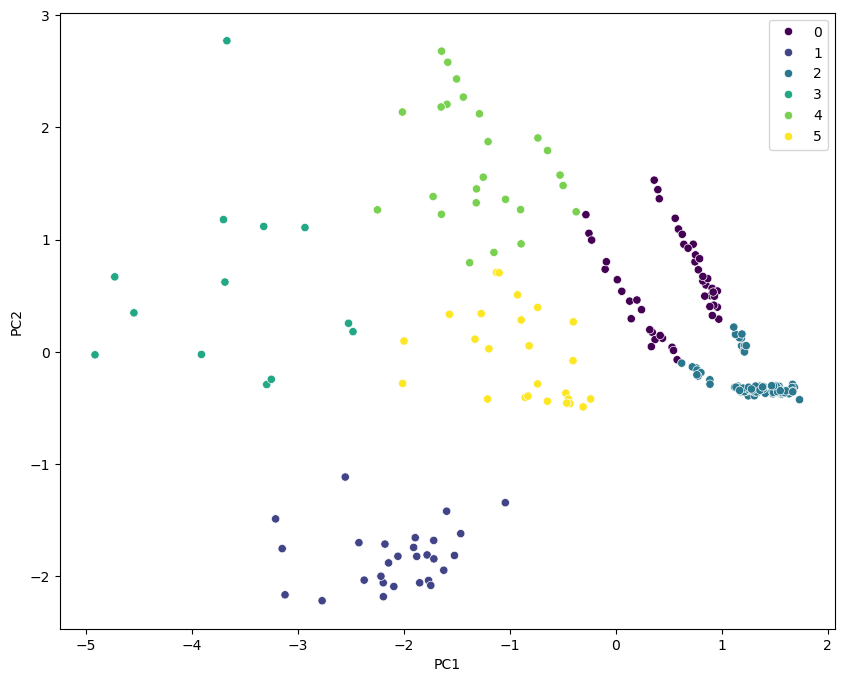

In [113]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=data_scaled_pca_cl[:, 0], y=data_scaled_pca_cl[:, 1], hue=labels, palette='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

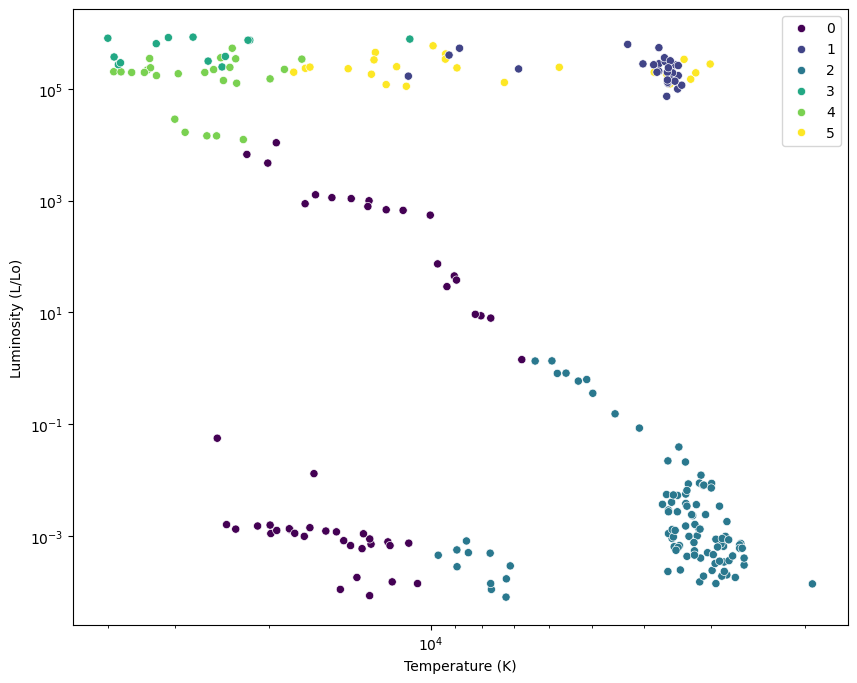

In [109]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_stars,
    x='Temperature (K)',
    y='Luminosity(L/Lo)',
    hue=kmeans_labels,
    palette='viridis',
    s=35,
)
plt.xscale('log')
plt.gca().invert_xaxis()
plt.yscale('log')
plt.xlabel('Temperature (K)')
plt.ylabel('Luminosity (L/Lo)')
plt.show()

### A powerfull technique: t-SNE

In [118]:
from sklearn.manifold import TSNE

In [128]:
tSNE = TSNE(n_components=2, random_state=42)
data_scaled_tSNE = tSNE.fit_transform(data_scaled)

data_scaled_tSNE.shape

(240, 2)

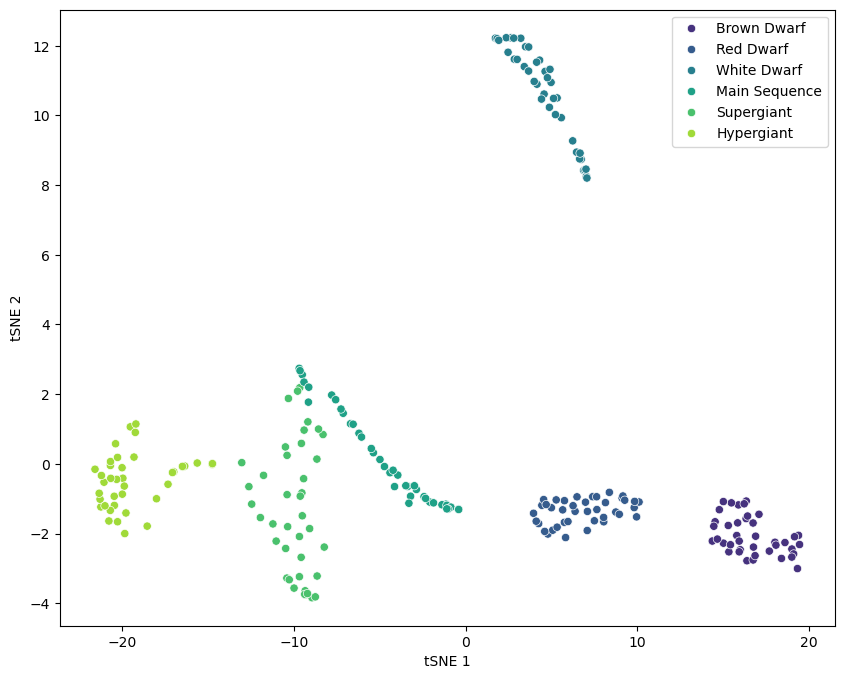

In [130]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=data_scaled_tSNE[:, 0], y=data_scaled_tSNE[:, 1], hue=le.inverse_transform(df_stars['Star type']), palette='viridis')
plt.xlabel('tSNE 1')
plt.ylabel('tSNE 2')
plt.show()

This what's obtained by already know the original classification, and it's remarkable indeed. 

Probabily running a KMeans algorithm on this reduced dataset will be more succesfull.

In [131]:
kmeans_tSNE = KMeans(n_clusters=6, random_state=42)
kmeans_tSNE.fit(data_scaled_tSNE)

kmeans_tSNE_labels = kmeans_tSNE.labels_

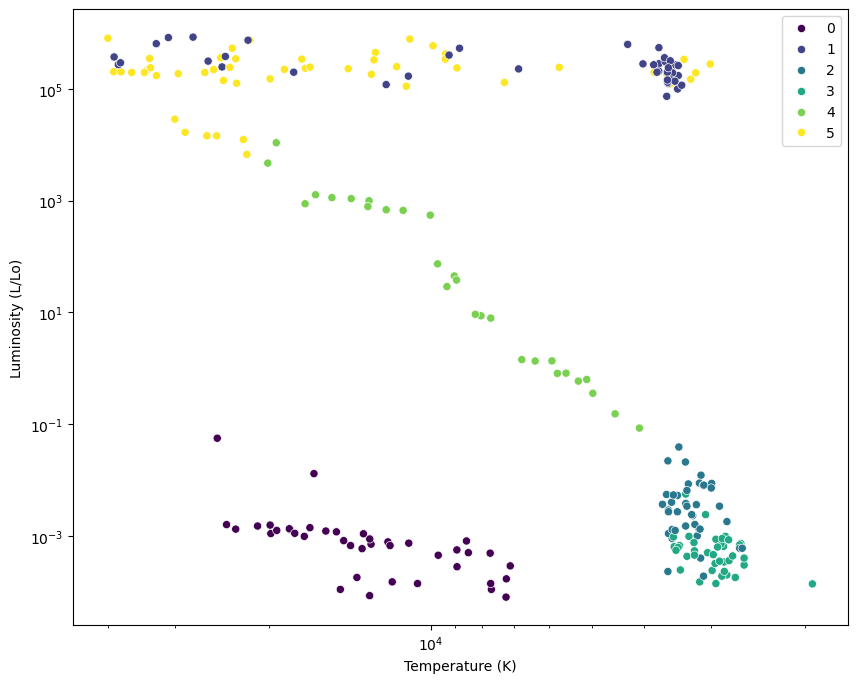

In [135]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_stars,
    x='Temperature (K)',
    y='Luminosity(L/Lo)',
    hue=kmeans_tSNE_labels,
    palette='viridis',
    s=35,
)
plt.xscale('log')
plt.gca().invert_xaxis()
plt.yscale('log')
plt.xlabel('Temperature (K)')
plt.ylabel('Luminosity (L/Lo)')
plt.show()